In [1]:
# these warnings are fine. you can ignore them.
from copy import deepcopy
import random, math
import statistics

from deeprobust.graph.data import Dataset as RDDataset
from deeprobust.graph.data import Pyg2Dpr, Pyg2Dpr
from deeprobust.graph.defense import GCNJaccard
from scipy.sparse import csr_matrix

import sys
sys.path.append('../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [2]:
jaccard_data = RDDataset(root='/tmp/', name="cora")
adj, features, labels = jaccard_data.adj, jaccard_data.features, jaccard_data.labels
idx_train, idx_val, idx_test = jaccard_data.idx_train, jaccard_data.idx_val, jaccard_data.idx_test

labels_copy = deepcopy(labels)
print(labels_copy.shape)

idx = np.concatenate([idx_train, idx_val, idx_test], axis=0)
np.sort(idx)

jaccard_in_feats = features.shape[1]
jaccard_h_feats = 64
jaccard_num_classes = labels.max() + 1

jaccard_model = get_model('../../../', jaccard_in_feats, jaccard_h_feats, jaccard_num_classes, 'cora', Models.GCNJACCARD)
jaccard_ground_truth = jaccard_model.test(idx_test)

Loading cora dataset...
Selecting 1 largest connected components
(2485,)
removed 572 edges in the original graph
Test set results: loss= 0.6607 accuracy= 0.7902


In [3]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()
data = data.to(device)

gcn_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GCN)
gcn_ground_truth = get_ground_truth(gcn_model, data, Models.GCN, testMask=True)[0]
print(gcn_ground_truth)

gsaint_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GSAINT, data=dataset)
gsaint_ground_truth = get_ground_truth(gsaint_model, data, Models.GSAINT, testMask=True)[0]
print(gsaint_ground_truth)

0.745
0.7699409158050221


In [4]:
print(dataset)

In [5]:
gat_model = get_model('../', in_feats, h_feats, num_classes, 'cora', Models.GAT)
gat_ground_truth = get_ground_truth(gat_model, data, Models.GAT, testMask=True)[0]
print(gat_ground_truth)

0.742


In [6]:
gsage_dataset = Planetoid(root='/tmp/Cora', name='Cora')
gsage_data = gsage_dataset[0]
gsage_data = gsage_data.to(device, 'x', 'edge_index')

gsage_model = get_model('../', gsage_data.num_node_features, 64, 7, 'cora', Models.GSAGE)

gsage_ground_truth = get_ground_truth(gsage_model, gsage_data, Models.GSAGE, testMask = False)[0]
print(gsage_ground_truth)

0.5384047267355982


In [7]:
ptb_rates = [0.05,  0.1, 0.15, 0.2, 0.25, 0.3]
gcn_vals = []
gat_vals = []
gsage_vals = []
gsaint_vals = []
jaccard_vals = []

In [8]:
homophilic_set = {label: [] for label in set(data.y.tolist())}

test_indices = torch.nonzero(data.test_mask, as_tuple=False).squeeze()
for i in test_indices:
    homophilic_set[data.y[i].item()].append(i.item())

In [10]:
c = 0.05
# 0.05, 0.1, 0.15, 0.2, 0.25

for p in ptb_rates:
    gcn_temp_vals = []
    gat_temp_vals = []
    gsage_temp_vals = []
    gsaint_temp_vals = []
    jaccard_temp_vals = []
    for i in range(0, 30):
        
        data = dataset.get_data()[0]
        modified_graph = data
        
        init_edges = len(modified_graph.edge_index[1])
        
        G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)
        train_mask = train_mask.to('cpu')
        test_mask = test_mask.to('cpu')
        
        blank_G = nx.Graph()
    
        for j in range(0, len(homophilic_set)):
            new_G = G.subgraph(homophilic_set[j])
            cc = sorted(nx.strongly_connected_components(new_G), key=len, reverse=True)
            for i in cc:
                s = set(i)
                if len(s) > 1 and nx.density(G.subgraph(i)) >= c:
                    make_clique(blank_G, s)  
    
        budget = math.floor(p * (G.number_of_edges() / 2))
        print(budget)
    
        blank_G = blank_G.to_undirected()
    
        print(blank_G.number_of_edges())
    
        add_G = nx.Graph()
        
        edges = [edge for edge in blank_G.edges() if edge not in G.edges()]
        
        random.shuffle(edges)
        
        # Select budget number of edges and add them to add_G
        selected_edges = edges[:budget]
        add_G.add_edges_from(selected_edges)
        add_G = add_G.to_directed()
        add_edges = add_G.edges()
    
        for (i, j) in add_G.edges():
            G.add_edge(i, j)
        
        modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
        final_edges = len(modified_graph.edge_index[1])
    
        # GCN
        acc = test_model(gcn_model, modified_graph, Models.GCN, testMask=True)[0]
        gcn_temp_vals.append(abs(acc - gcn_ground_truth))
    
        # GAT
        acc = test_model(gat_model, modified_graph, Models.GAT, testMask=True)[0]
        gat_temp_vals.append(abs(acc - gat_ground_truth))
    
        # GSAINT
        acc = test_model(gsaint_model, modified_graph, Models.GSAINT, testMask=True)[0]
        gsaint_temp_vals.append(abs(acc - gsaint_ground_truth))
    
        # GSAGE
        gsage_graph = modified_graph.to(device, 'x', 'edge_index')
        acc = get_ground_truth(gsage_model, gsage_graph, Models.GSAGE, testMask = False)[0]
        gsage_temp_vals.append(abs(acc - gsage_ground_truth))
            
        # # JACCARD
        # modified_adj = model.modified_adj # modified_adj is a torch.tensor
        # modified_adj = modified_adj.cpu().numpy()
        # modified_adj = csr_matrix(modified_adj)
    
        # atk_model = GCNJaccard(nfeat=features.shape[1],
        #       nhid=64,
        #       nclass=labels.max().item() + 1,
        #       dropout=0.5, device=device).to(device)
        # atk_model.fit(features, modified_adj, labels, idx_train, idx_val, patience=100, verbose=True)
        
        # atk_acc = atk_model.test(idx_test)
    
        # print(jaccard_data.adj)
    
        adj_matrix = nx.adjacency_matrix(G)
        adj_matrix_array = adj_matrix.toarray()
        adj_tensor = torch.tensor(adj_matrix_array).cpu().numpy()
        # jaccard_data = RDDataset(root='/tmp/', name="cora")
        # labels = jaccard_data.labels
        # print(adj_tensor.shape)
        # print(labels_copy.shape)
        # adj_tensor = csr_matrix(adj_tensor)
        
        # jaccard_model = get_model('../../../', jaccard_in_feats, jaccard_h_feats, jaccard_num_classes, 'cora', Models.GCNJACCARD)
        # jaccard_model.fit(features, adj_tensor, labels, idx_train, idx_val, patience=100, verbose=True)
        new_jaccard_model = GCNJaccard(nfeat=in_feats,
              nhid=64,
              nclass=jaccard_num_classes,
              dropout=0.5, device='cpu')
        new_jaccard_model.fit(np.array(x.cpu(), dtype=np.float64), adj_tensor, y.cpu(), train_mask.cpu(), idx_val=None, patience=100, verbose=False)
        acc = new_jaccard_model.test(test_mask.cpu())
        jaccard_temp_vals.append(abs(acc - jaccard_ground_truth))

    
    # print(atk_acc)
    
    # jaccard_g = Dpr2Pyg(jaccard_data)[0].to('cpu')
    # jaccard_g = jaccard_g.to('cpu')
    # add_edges = [(int(edge[0]), int(edge[1])) for edge in add_edges]
    # add_edges_tensor = torch.tensor(add_edges, dtype=torch.long).t().to('cpu')
    # new_edge_index = torch.cat([jaccard_g.edge_index, add_edges_tensor], dim=1)
    # jaccard_g.edge_index = new_edge_index.to('cpu')
    # # add edge from add_edges list here
    # jaccard_new_data = Pyg2Dpr([jaccard_back])
    

    # print(dpr_data)
    # jaccard_model.fit(features, Pyg2Dpr(modified_graph), labels, [], [], threshold=0.01)
    # # model.eval()
    # acc = model.test(Pyg2Dpr(modified_graph).idx_test)
    # jaccard_vals.append(acc - jaccard_ground_truth)
    
    # number_added_edges(init_edges, final_edges, is_undirected=True)   
    jaccard_vals.append(statistics.median(jaccard_temp_vals))
    gcn_vals.append(statistics.median(gcn_temp_vals))
    gat_vals.append(statistics.median(gat_temp_vals))
    gsage_vals.append(statistics.median(gsage_temp_vals))
    gsaint_vals.append(statistics.median(gsaint_temp_vals))
    # jaccard_vals.append(sum(jaccard_temp_vals) / len(jaccard_temp_vals))
    # gcn_vals.append(sum(gcn_temp_vals) / len(gcn_temp_vals))
    # gat_vals.append(sum(gat_temp_vals) / len(gat_temp_vals))
    # gsage_vals.append(sum(gsage_temp_vals) / len(gsage_temp_vals))
    # gsaint_vals.append(sum(gsaint_temp_vals) / len(gsaint_temp_vals))
    print("For c value:", c)

263
2536
removed 639 edges in the original graph
Test set results: loss= 0.6821 accuracy= 0.7910
263
2536
removed 621 edges in the original graph
Test set results: loss= 0.7057 accuracy= 0.7700
263
2536
removed 636 edges in the original graph
Test set results: loss= 0.6984 accuracy= 0.7770
263
2536
removed 628 edges in the original graph
Test set results: loss= 0.6773 accuracy= 0.7900
263
2536
removed 635 edges in the original graph
Test set results: loss= 0.6825 accuracy= 0.7930
263
2536
removed 631 edges in the original graph
Test set results: loss= 0.6475 accuracy= 0.7980
263
2536
removed 626 edges in the original graph
Test set results: loss= 0.6793 accuracy= 0.7970
263
2536
removed 635 edges in the original graph
Test set results: loss= 0.7132 accuracy= 0.7810
263
2536
removed 628 edges in the original graph
Test set results: loss= 0.6981 accuracy= 0.7830
263
2536
removed 623 edges in the original graph
Test set results: loss= 0.7049 accuracy= 0.7830
263
2536
removed 626 edges in 

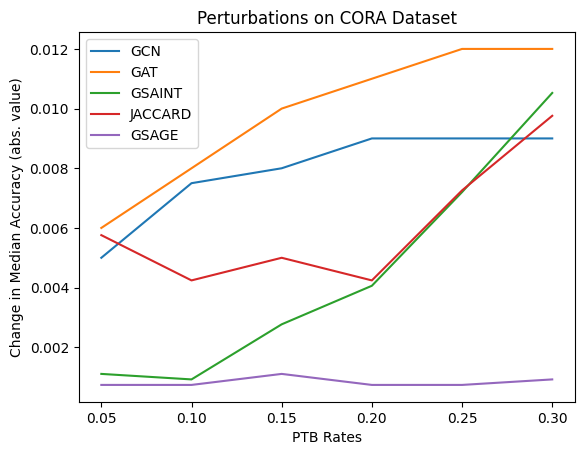

In [11]:
import matplotlib.pyplot as plt

# x axis
ptb_rates = [0.05,  0.1, 0.15, 0.2, 0.25, 0.3]

# Plot each line with a label
plt.plot(ptb_rates, gcn_vals, label="GCN")
plt.plot(ptb_rates, gat_vals, label="GAT")
plt.plot(ptb_rates, gsaint_vals, label="GSAINT")
plt.plot(ptb_rates, jaccard_vals, label="JACCARD")
plt.plot(ptb_rates, gsage_vals, label="GSAGE")

# Adding labels and title
plt.xlabel('PTB Rates')
plt.ylabel('Change in Median Accuracy (abs. value)')
plt.title('Perturbations on CORA Dataset')
plt.legend()

# Show the plot
output_path = "./data/cora_graph_median.png"
plt.savefig(output_path)

plt.show()

In [12]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/cora/gcn_results_median.npy',
    f'./data-arrays/cora/gat_results_median.npy',
    f'./data-arrays/cora/jaccard_results_median.npy',
    f'./data-arrays/cora/gsage_results_median.npy',
    f'./data-arrays/cora/gsaint_results_median.npy',
    f'./data-arrays/cora/ptb_rates.npy'
]

results = [
    np.array(gcn_vals),
    np.array(gat_vals),
    np.array(jaccard_vals),
    np.array(gsage_vals),
    np.array(gsaint_vals),
    np.array(ptb_rates)
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)